In [399]:
import gc
import os
import sys
from dataclasses import dataclass
# from google.colab import userdata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pprint import pprint
from typing import Callable
from datetime import datetime

import random
# from tqdm import tqdm
import time
from tqdm.autonotebook import tqdm as notebook_tqdm
import torch
from torch.utils.data import Dataset, DataLoader
# torch.set_float32_matmul_precision('high')

from huggingface_hub import login
import transformers
from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM, AutoConfig, logging, AutoModelForMaskedLM
from langchain_text_splitters import RecursiveCharacterTextSplitter

import warnings
warnings.filterwarnings('ignore')

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
gc.collect()
torch.cuda.empty_cache()

In [3]:
sys.version

'3.11.11 | packaged by conda-forge | (main, Mar  3 2025, 20:43:55) [GCC 13.3.0]'

In [70]:
class Dataset10x(Dataset):
    def __init__(self, report_df: pd.DataFrame, items_path: str = 'items') -> None:
        super().__init__()

        self.target_columns = ['FILING_DATE', 'CIK', 'ACC_NUM']
        for col in self.target_columns:
            assert col in report_df.columns, col

        self.name_columns = [self.target_columns[0], '10-K_edgar_data'] + self.target_columns[1:]
        self.item_names = ['item1', 'item1a', 'item7']
        self.items_path = items_path
        self.report_df = report_df

    def __len__(self) -> int:
        return len(self.report_df)

    def __getitem__(self, idx: int) -> dict[str, str]:
        report_dict = {}
        notnone = False
        report = self.report_df.iloc[idx].to_dict()
        report_name = '_'.join([str(report[x]) if x in report.keys() else x for x in self.name_columns])

        for item_name in self.item_names:
            item_pathname = os.path.join(self.items_path, f'{item_name}_files', f'{report_name}_{item_name}.txt')

            if not os.path.exists(item_pathname):
                item_pathname = os.path.join(self.items_path, f'{report_name}_{item_name}.txt')

            if os.path.exists(item_pathname):
                with open(item_pathname, 'r', encoding='utf-8') as file:
                    item_text = file.read()
                    report_dict[item_name] = item_text
                    notnone = True
        return (idx, report_dict) if notnone else (idx, None)

def collate_fn_item7(batch):
    indices = []
    item7_texts = []
    
    for idx, data in batch:
        if data is not None and "item7" in data:
            item7 = data["item7"]
#             if len(item7) > 200:
            indices.append(idx)
            item7_texts.append(item7)
    return indices, item7_texts

In [71]:
def fill_prompt_batch(texts, ending, prompt_func, tokenizer, model,
                      top_k=1, top_p=None, text_length=1000, verbose=False, device='cuda'):
    """
    - Generates tokens for a batch of texts
    - Uses model to obtain the logits (prob to fill mask)
    - Returns the top_k tokens and associated probs
    """
    clean_mem()

    prompt_texts = [prompt_func(text[:text_length], ending) for text in texts]
    
    inputs = tokenizer(prompt_texts, return_tensors="pt", truncation=True,
                       padding='max_length').to(device)
    
    if verbose:
        print(inputs['input_ids'].shape)

    with torch.no_grad():
        logits = model(**inputs).logits.cpu()

#     probss = torch.nn.functional.softmax(logits[:,-1,:], dim=-1)
    pad_ix = (inputs["input_ids"]==tokenizer.mask_token_id).cpu()    # batch_size, vocab_size
    answer_logits = logits[pad_ix]
    answer_probs = torch.nn.functional.softmax(answer_logits, dim=-1)

    del inputs
    gc.collect()
    
    if top_p is not None and top_p>0 and top_p<=1.0:
        sorted_probs, sorted_indices = torch.sort(answer_probs, descending=True, dim=-1)    # batch_size by vocab_size
        cumulative_probs = torch.cumsum(sorted_probs, dim=-1)
        # Remove tokens with cumulative probability above the threshold
        sorted_indices_to_keep = cumulative_probs <= top_p                           # top_p
        # Shift the indices to the right to keep also the first token above the threshold
        sorted_indices_to_keep[..., 1:] = sorted_indices_to_keep[..., :-1].clone()
        sorted_indices_to_keep[..., 0] = True
        indices_to_keep = [sorted_indices[i][sorted_indices_to_keep[i]].tolist() for i in range(len(sorted_indices))]
        probs_to_keep = [sorted_probs[i][sorted_indices_to_keep[i]].tolist()  for i in range(len(sorted_indices))]
        answers = [dict(zip(l.strip().split(),probs_to_keep[i]))
                  for i,l in enumerate(tokenizer.batch_decode(indices_to_keep))]
        return answers
    
    else:
        top_k_tokens = torch.topk(answer_probs, top_k, dim=1).indices.tolist()
        top_k_probs = torch.topk(answer_probs, top_k, dim=1).values.tolist()
        top_k_decoded = tokenizer.batch_decode(top_k_tokens)
        return [dict(zip(d.strip().split(" "), top_k_probs[i])) for i,d in enumerate(top_k_decoded)]

In [72]:
def apply_strategy(texts, ending, strategy, tokenizer, model, text_length=5000, verbose=False, device='cuda'):
    '''
    Applies prompt strategy

    - text: to be appended the prompt
    - strategy: contains the prompt and the verbalizer
    '''

    output = fill_prompt_batch(texts, ending, strategy.prompt, tokenizer=tokenizer,
                               model=model, top_p=strategy.top_p, text_length=text_length, device=device)
    clean_mem()

    scores = []
    for item in output:
        score = dict()
        for cat, vals in strategy.verbalizer.items():
            # Strip spaces + turn lowercase, then match with verbalizer
            score[cat] = sum([v for k,v in item.items() if k.strip().lower() in vals])
            try:
                score['polarity'] = score['positive'] - score['negative']
            except Exception:
                pass
        scores.append(score)

    if verbose:
        print(scores)
    return scores

In [73]:
def get_model_output(prompt, model, device, k=20) -> dict[str, float]:

    inputs = tokenizer(prompt, return_tensors='pt', truncation=True,
                     padding='max_length').to(device)

    print(f"input has {inputs['input_ids'].shape} tokens")

    with torch.no_grad():
        logits = model(**inputs).logits.cpu()

#     logits = logits[0,-1,:]
#     probs = torch.nn.functional.softmax(logits, dim=-1)

    pad_ix = (inputs["input_ids"]==tokenizer.mask_token_id).cpu()    # batch_size, vocab_size
    answer_logits = logits[pad_ix]
    answer_probs = torch.nn.functional.softmax(answer_logits, dim=-1)
    
    top_k_tokens = torch.topk(answer_probs, k, dim=1)
    top_ix = top_k_tokens.indices.tolist()[0]
    top_prob = top_k_tokens.values.tolist()[0]

    # return dict(zip(top_ix, top_prob))
    return dict(zip([tokenizer.decode([x]) for x in top_ix], top_prob))

In [74]:
def clean_mem():
    import gc
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    time.sleep(0.1)

In [393]:
def gather_stats(strategy, results, tokenizer, model, data, ending, verbose=False, text_length=5000, 
                save_path="results", save_interval=5000, resume=True, max_retries=3, device='cuda'):
    
    if resume and results:
        max_processed_idx = max([df.index.max() for df in results if not df.empty])
        print(f"Resuming from index: {max_processed_idx}")
    else:
        max_processed_idx = -1
    
    processed_count = 0
    batch_count = 0
    
    for doc_indices, batch_chunks, chunks_per_doc in notebook_tqdm(data):
        if len(doc_indices) > 0:
            if resume and max(doc_indices) <= max_processed_idx:
                continue
            else:
                success = False
                retry_count = 0

                while not success and retry_count < max_retries:
                    try:
                        # Применяем стратегию ко всем чанкам
                        chunk_scores = apply_strategy(batch_chunks, ending, strategy=strategy, 
                                                     tokenizer=tokenizer, model=model, 
                                                     text_length=text_length, device=device)
                        clean_mem()
                        
                        # Агрегируем результаты по документам
                        doc_scores = []
                        start_idx = 0
                        for doc_idx, num_chunks in zip(np.unique(doc_indices), chunks_per_doc):
                            if num_chunks == 0:
                                continue
                            
                            # Получаем скоры для всех чанков этого документа
                            doc_chunk_scores = chunk_scores[start_idx:start_idx + num_chunks]
                            start_idx += num_chunks
                            
                            # Агрегируем скоры (например, среднее по всем чанкам)
                            aggregated_score = {}
                            for key in doc_chunk_scores[0].keys():
                                values = [score[key] for score in doc_chunk_scores if key in score]
                                aggregated_score[key] = sum(values) / len(values) if values else 0
                            
                            doc_scores.append((doc_idx, aggregated_score))
                        
                        # Сохраняем результаты
                        indices = [idx for idx, _ in doc_scores]
                        scores = [score for _, score in doc_scores]
                        
                        df = pd.DataFrame(scores, index=indices)
                        results.append(df)
                        processed_count += len(indices)
                        batch_count += 1

                        success = True

                    except torch.cuda.OutOfMemoryError as oom_error:
                        retry_count += 1
                        print(f"CUDA OOM error processing batch {doc_indices} (attempt {retry_count}): {oom_error}")
                        
                        clean_mem()
                        if torch.cuda.is_available():
                            torch.cuda.empty_cache()
                        
                        if retry_count >= max_retries:
                            print(f"Failed to process batch after {max_retries} attempts")
                            break
                    
                    except Exception as e:
#                         print(f"Error processing batch with indices {doc_indices}: {e}")
                        break
                
                # Сохранение промежуточных результатов
                if processed_count >= save_interval:
                    try:
                        stats_df = pd.concat(results, axis=0)
                        stats_df.reset_index(inplace=True)
                        
                        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
                        csv_file = os.path.join(save_path, f"results_{timestamp}_{processed_count}_reports.csv")
                        stats_df.to_csv(csv_file, index=False)
                        
                        processed_count = 0
                        
                    except Exception as e:
                        print(f"Error saving intermediate results: {e}")
        
        else:
            continue
    
    # Финальное сохранение
    if results:
        try:
            stats_df = pd.concat(results, axis=0)
            stats_df.reset_index(inplace=True)
            
            final_csv_file = os.path.join(save_path, "final_results.csv")
            stats_df.to_csv(final_csv_file, index=False)
            
            if verbose:
                print(stats_df.info())
            
            return stats_df
        
        except Exception as e:
            print(f"Error saving final results: {e}")
            return pd.DataFrame()
    else:
        print("No results to process")
        return pd.DataFrame()

In [400]:
def calculate_mean_polarities(tech_res, blue_chip_res):
    result_dict = {}
    tech_sent_before_crisis = tech_res[tech_res['FILING_DATE'].astype(str).str[:4].between('1997', '1999')].reset_index(drop=True)
    tech_sent_after_crisis = tech_res[tech_res['FILING_DATE'].astype(str).str[:4].between('2000', '2003')].reset_index(drop=True)

    blue_chip_before_crisis = blue_chip_res[blue_chip_res['FILING_DATE'].astype(str).str[:4].between('1997', '1999')].reset_index(drop=True)
    blue_chip_after_crisis = blue_chip_res[blue_chip_res['FILING_DATE'].astype(str).str[:4].between('2000', '2003')].reset_index(drop=True)
    
    tech_line = [tech_sent_before_crisis['polarity'].mean(), tech_sent_after_crisis['polarity'].mean()]
    result_dict['tech'] = {}
    result_dict['tech']['before'] = tech_line[0]
    result_dict['tech']['after'] = tech_line[1]

    blue_chip_line = [blue_chip_before_crisis['polarity'].mean(), blue_chip_after_crisis['polarity'].mean()]
    delta = blue_chip_line[0] - blue_chip_line[1]
    result_dict['blue_chip'] = {}
    result_dict['blue_chip']['before'] = blue_chip_line[0]
    result_dict['blue_chip']['after'] = blue_chip_line[1]
    
    res_df = pd.DataFrame.from_dict(result_dict).T
    res_df['delta'] = res_df['before'] - res_df['after']
    res_df = round(res_df, 4)
    display(res_df)
    
    plt.title('Polarity general ModernBERT', weight='bold')
    plt.plot(tech_line, marker='o', label='tech')
    plt.plot(blue_chip_line, marker='o', label='non-tech')

    # for i in range(len(tech_line)):
    #     plt.text(i, tech_line[i], f'  {tech_line[i]:.3f}', va='bottom', ha='left', fontsize=9)
    #     plt.text(i, blue_chip_line[i], f'  {blue_chip_line[i]:.3f}', va='bottom', ha='left', fontsize=9)

    plt.ylabel('mean sentiment')
    plt.xticks(ticks=[0, 1], labels=['before crisis (1997 -- 1999)', 'after crisis (2001 -- 2003)'])
    plt.legend()
    plt.grid()

    return tech_line, blue_chip_line, result_dict

def calc_tech_and_blue_chip_sent(model, blue_chip_dataloader, tech_dataloader, ending, sentiment_verb, text_length=10_000):
    sentiment_strategy = Prompt_Strategy('sentiment', sentiment_verb, get_prompt)
    
    results = []

    blue_chip_sent = gather_stats(
        sentiment_strategy, results=results, tokenizer=tokenizer, model=model,
        data=blue_chip_dataloader, ending=ending, verbose=False, text_length=text_length, 
        save_path="/home/jovyan/datavol-1/project_10x/speculative_sent/blue_chip_sentiment/",
        save_interval=2000, resume=True, max_retries=3, device=device
    )

    blue_chip_res = blue_chip_df.join(blue_chip_sent)
    clean_mem()
    
    results = []

    tech_sent = gather_stats(
        sentiment_strategy, results=results, tokenizer=tokenizer, model=model,
        data=tech_dataloader, ending=ending, verbose=False, text_length=text_length, 
        save_path="/home/jovyan/datavol-1/project_10x/speculative_sent/tech_sentiment/",
        save_interval=2000, resume=True, max_retries=3, device=device
    )

    tech_res = tech_df.join(tech_sent)
    clean_mem()
    
    return tech_res, blue_chip_res

# Data

In [11]:
df = pd.read_sas('/home/jovyan/datavol-1/project_10x/finaldata_10k.sas7bdat')

df['ACC_NUM'] = df['filename'].astype(str).str.split('_').str[1]
df['CIK'] = df['filename'].astype(str).str.split('_').str[0]
df['FILING_DATE'] = df['date_filed'].astype(str).str.replace('-', '')
reports = df
reports
# reports = df[df['FILING_DATE'].astype(str).str[:4] < '2013'].reset_index(drop=True)
# reports = reports[['CIK', 'FILING_DATE', 'ACC_NUM']]
# reports

# df = pd.read_csv('/home/jovyan/datavol-2/missing_item7.tsv.gz', sep='\t')
# df['ACC_NUM'] = df['name'].astype(str).str.split('_').str[-1]
# df['CIK'] = df['name'].astype(str).str.split('_').str[-2]
# df['FILING_DATE'] = df['name'].astype(str).str.split('_').str[0]
# reports = df[['CIK', 'FILING_DATE', 'ACC_NUM']]
# reports

,gvkey,datadate,prcc_f,csho,ceq,instown,permco,permno,date_filed,filename,...,tone_harvard,rfpred_car01,svrpred_car01,sldapred_car01,year,ln_mve,factorpred_car01,ACC_NUM,CIK,FILING_DATE
0,b'001004',1996-05-31,22.124999,15.998,204.635,0.769911,20000.0,54594.0,1996-08-20,b'1750_0000912057-96-018355',...,0.299376,0.005316,0.031102,0.000190,1996.0,5.869172,0.661720,0000912057-96-018355,1750,19960820
1,b'001004',1997-05-31,30.999985,18.204,269.259,0.832853,20000.0,54594.0,1997-08-22,b'1750_0000912057-97-028915',...,0.349099,0.000997,-0.008040,0.000435,1997.0,6.335628,-0.175370,0000912057-97-028915,1750,19970822
2,b'001004',1998-05-31,26.437500,27.704,300.850,0.893793,20000.0,54594.0,1998-08-20,b'1750_0001047469-98-032283',...,0.380851,0.002169,0.024143,-0.000279,1998.0,6.596360,0.229395,0001047469-98-032283,1750,19980820
3,b'001004',1999-05-31,19.750000,27.381,326.035,0.804165,20000.0,54594.0,1999-08-18,b'1750_0001047469-99-032978',...,0.415094,0.007558,0.016321,0.002568,1999.0,6.293003,0.567987,0001047469-99-032978,1750,19990818
4,b'001004',2000-05-31,13.875000,26.865,339.515,0.727921,20000.0,54594.0,2000-08-24,b'1750_0000912057-00-039006',...,0.386813,0.006785,0.020566,0.001088,2000.0,5.920913,0.476806,0000912057-00-039006,1750,20000824
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75357,b'317264',2017-03-31,10.530000,54.975,976.002,0.000000,54852.0,14642.0,2017-06-14,b'1596993_0001596993-17-000010',...,0.233754,-0.007481,0.061267,-0.005647,2017.0,6.361107,-0.123893,0001596993-17-000010,1596993,20170614
75358,b'317264',2018-03-31,7.490000,55.090,959.413,0.565377,54852.0,14642.0,2018-06-28,b'1596993_0001596993-18-000015',...,0.229364,-0.012188,0.007985,0.001820,2018.0,6.022537,-0.338591,0001596993-18-000015,1596993,20180628
75359,b'317264',2019-03-31,6.420000,55.168,912.683,0.529435,54852.0,14642.0,2019-05-30,b'1596993_0001596993-19-000010',...,0.259187,-0.016984,-0.063728,0.008236,2019.0,5.869801,-0.797175,0001596993-19-000010,1596993,20190530
75360,b'318728',2017-12-31,51.710000,199.853,9208.000,0.000000,55804.0,16496.0,2018-02-26,b'1527469_0001527469-18-000011',...,0.230316,0.001199,0.015440,0.010414,2018.0,9.243233,0.560623,0001527469-18-000011,1527469,20180226


In [12]:
summary = pd.read_csv('/home/jovyan/datavol-1/project_10x/Loughran-McDonald_10X_Summaries_1993-2023.csv')

tech_names = ['CISCO', 'AMAZON ', 'ETOYS', 'INTEL ', 'NETSCAPE', 'PETS ', 'NETSCAPE', 'YAHOO', 'FLOOZ', 'GEEKNET',
            'INTERACTIVE INTELLIGENCE', 'NETWORK SOLUTIONS', 'PALM', 'PIXELON', 'QUALCOMM', 'STEEL CONNECT', 'TRANSMETA',
            'UUNET', 'VERIO', 'TIBCO', 'UBID', 'WEBVAN']

blue_chip_names = ['COCA COLA', 'AT&T', 'PHILIP MORRIS', 'DUPONT', 'MERCK', 'GENERAL ELECTRIC']

selected_columns = ['CIK', "FILING_DATE", 'ACC_NUM', 'CoName']

tech_df = summary[summary['CoName'].str.startswith(tuple(tech_names))][selected_columns].reset_index(drop=True)
tech_df = tech_df[tech_df['FILING_DATE'].astype(str).str[:4].between('1997', '2003')].reset_index(drop=True)

blue_chip_df = summary[summary['CoName'].str.startswith(tuple(blue_chip_names))][selected_columns].reset_index(drop=True)
blue_chip_df = blue_chip_df[blue_chip_df['FILING_DATE'].astype(str).str[:4].between('1997', '2003')].reset_index(drop=True)

In [13]:
items_path = '/home/jovyan/datavol-1/project_10x/items/item7_files'
# items_path = '/home/jovyan/datavol-2/missing_item7'

tech_dataset = Dataset10x(tech_df, items_path)

not_none = []
for idx in range(393):
    item_dict = tech_dataset[idx]
    if item_dict[1] is not None:
        not_none.append(idx)
        
# len(not_none)
tech_df = tech_df.iloc[not_none].reset_index(drop=True)

In [14]:
blue_chip_dataset = Dataset10x(blue_chip_df, items_path)

not_none = []
for idx in range(402):
    item_dict = blue_chip_dataset[idx]
    if item_dict[1] is not None:
        not_none.append(idx)
        
blue_chip_df = blue_chip_df.iloc[not_none].reset_index(drop=True)

In [15]:
blue_chip_df.shape, tech_df.shape

((35, 4), (49, 4))

# Model - ModernBERT

In [17]:
model_id = "/home/jovyan/models/ModernBERT-large"

device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(model_id,
#                                           max_length=length,
                                          padding=True,
                                          truncation=True,
                                          cache_dir="hf_cache")
if not tokenizer.pad_token:
    print("Adding pad token")
    tokenizer.pad_token = tokenizer.eos_token
    
tokenizer.padding_side = "left"

model = AutoModelForMaskedLM.from_pretrained(
    model_id, torch_dtype=torch.bfloat16, cache_dir="hf_cache"
).to(device)

In [57]:
config = AutoConfig.from_pretrained(model_id)
length = config.max_position_embeddings
length

8192

In [22]:
item_name = 'item7'

q99 = 275568
q95 = 169981

In [23]:
def get_prompt(item_text: str, ending: str) -> str:
    return item_text + "\n\n" + ending 

## Dataloader

In [369]:
batch_size = 2

blue_chip_dataset = Dataset10x(blue_chip_df, items_path)
tech_dataset = Dataset10x(tech_df, items_path)

# blue_chip_dataloader = DataLoader(blue_chip_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_item7)
# tech_dataloader = DataLoader(tech_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_item7)

In [370]:
splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(tokenizer=tokenizer,
                                                                     chunk_size=length,
                                                                     chunk_overlap=240)

def split_collator(batch):
    all_chunks = []
    doc_indices = []  # Индекс документа для каждого чанка
    chunks_per_doc = []  # Количество чанков для каждого документа
    
    for idx, data in batch:
        if data is not None and "item7" in data:
            text = data['item7']
            chunks = splitter.split_text(text)
            all_chunks.extend(chunks)
            # Добавляем индекс документа для каждого чанка
            doc_indices.extend([idx] * len(chunks))
            chunks_per_doc.append(len(chunks))
    
    return doc_indices, all_chunks, chunks_per_doc

In [371]:
blue_chip_dataloader = DataLoader(
    blue_chip_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=split_collator
)

tech_dataloader = DataLoader(
    tech_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=split_collator
)

## Example

In [24]:
text = "The capital of France is [MASK]."

inputs = tokenizer([text, text+" Another sentence of stuff."], return_tensors="pt", truncation=True, padding='max_length').to(device)
with torch.no_grad():
    outputs = model(**inputs)

masked_index = inputs["input_ids"][0].tolist().index(tokenizer.mask_token_id)
predicted_token_id = outputs.logits[0, masked_index].argmax(axis=-1)
predicted_token = tokenizer.decode(predicted_token_id)
print("Predicted token:", predicted_token)

Predicted token:  Paris


In [25]:
item_text = "Some text."

ending = "The capital of France is [MASK]."

prompt = get_prompt(item_text, ending)
probs = get_model_output(prompt, model, device, k=20)
probs

input has torch.Size([1, 8192]) tokens


{' Paris': 0.97265625,
 ' Nice': 0.0157470703125,
 ' Lyon': 0.0084228515625,
 ' France': 0.001068115234375,
 ' Tours': 0.000690460205078125,
 ' Nancy': 0.000392913818359375,
 'Paris': 0.0002536773681640625,
 ' Brussels': 0.00017452239990234375,
 ' Rome': 0.000164031982421875,
 ' Geneva': 0.0001277923583984375,
 ' Orleans': 9.34600830078125e-05,
 ' London': 6.437301635742188e-05,
 ' 1': 5.6743621826171875e-05,
 'Nice': 5.0067901611328125e-05,
 ' so': 4.410743713378906e-05,
 '...': 3.647804260253906e-05,
 ' ""': 3.0279159545898438e-05,
 ' Madrid': 2.849102020263672e-05,
 '\n': 2.6702880859375e-05,
 ' Barcelona': 2.3603439331054688e-05}

## Report probabilities

In [46]:
idx = 29

item_dict = blue_chip_dataset[idx]
date = blue_chip_df.iloc[idx].FILING_DATE
item_text = item_dict[1].get(item_name)[:50_000]

co_name = blue_chip_df.iloc[idx]['CoName']

print(f"{co_name}, date: {date}")

AT&T WIRELESS SERVICES INC, date: 20030325


In [34]:
# len(item_dict[1].get(item_name))

In [160]:
pprint(item_text)

("      Item 7. Management's Discussion and Analysis of Financial Condition "
 'and Results of Operations \n'
 '        The following discussion and analysis of financial condition and '
 'results of operations should be read in conjunction with our consolidated '
 'financial statements and related notes included elsewhere in this document. '
 'All references to years are to our fiscal years, which end on June 30.\n'
 'Overview \n'
 '         Based on worldwide revenue, we are one of the largest photomask '
 'manufacturers in the world. We sell our products to over 400 customers and '
 'customer sites in more than 20 different countries. Essentially all of our '
 'sales are to customers in the semiconductor manufacturing industry. We '
 'manufacture a broad range of photomasks based on customer-supplied design '
 'data. We operate globally with established manufacturing facilities in North '
 'America, Europe and Asia. \n'
 '         We believe that over the long-term, the market for p

In [47]:
ending = "In summary, we are [MASK] regarding the future growth of our company."

prompt = get_prompt(item_text, ending)
probs = get_model_output(prompt, model, device, k=20)
probs

input has torch.Size([1, 8192]) tokens


{' uncertain': 0.1943359375,
 ' confident': 0.1513671875,
 ' cautious': 0.10400390625,
 ' optimistic': 0.10400390625,
 ' concerned': 0.0712890625,
 ' unsure': 0.02978515625,
 ' doubtful': 0.02978515625,
 ' skeptical': 0.0279541015625,
 ' conservative': 0.01495361328125,
 ' critical': 0.0096435546875,
 ' neutral': 0.006256103515625,
 ' certain': 0.005859375,
 ' unclear': 0.005523681640625,
 ' positive': 0.005523681640625,
 ' advised': 0.00518798828125,
 ' uncertainty': 0.00518798828125,
 ' reserved': 0.004852294921875,
 ' negative': 0.004302978515625,
 ' disappointed': 0.0040283203125,
 ' limited': 0.0040283203125}

In [48]:
idx = 33

item_dict = blue_chip_dataset[idx]
item_text = item_dict[1].get(item_name)[:50_000]

prompt = get_prompt(item_text, ending)
probs = get_model_output(prompt, model, device)
probs

input has torch.Size([1, 8192]) tokens


{' optimistic': 0.5546875,
 ' confident': 0.2041015625,
 ' uncertain': 0.0751953125,
 ' cautious': 0.0216064453125,
 ' hopeful': 0.0167236328125,
 ' concerned': 0.01483154296875,
 ' certain': 0.0108642578125,
 ' unsure': 0.006988525390625,
 ' enthusiastic': 0.00579833984375,
 ' positive': 0.005126953125,
 ' doubtful': 0.003997802734375,
 ' excited': 0.003997802734375,
 ' skeptical': 0.0033111572265625,
 ' realistic': 0.0030975341796875,
 ' conservative': 0.0029144287109375,
 ' serious': 0.0029144287109375,
 ' projecting': 0.00177001953125,
 ' neutral': 0.00177001953125,
 ' aggressive': 0.00156402587890625,
 ' speculative': 0.00156402587890625}

In [51]:
idx = 34

item_dict = blue_chip_dataset[idx]
item_text = item_dict[1].get(item_name)[:40_000]

prompt = get_prompt(item_text, ending)
probs = get_model_output(prompt, model, device)
probs

input has torch.Size([1, 8192]) tokens


{' confident': 0.2578125,
 ' optimistic': 0.1767578125,
 ' uncertain': 0.12158203125,
 ' concerned': 0.057373046875,
 ' unsure': 0.034912109375,
 ' cautious': 0.02880859375,
 ' doubtful': 0.0224609375,
 ' committed': 0.0164794921875,
 ' advised': 0.0145263671875,
 ' certain': 0.0128173828125,
 ' skeptical': 0.0106201171875,
 ' positive': 0.006866455078125,
 ' determined': 0.00604248046875,
 ' satisfied': 0.00567626953125,
 ' hopeful': 0.0050048828125,
 ' convinced': 0.0050048828125,
 ' conservative': 0.00469970703125,
 ' interested': 0.004425048828125,
 ' encouraged': 0.004425048828125,
 ' disappointed': 0.00390625}

In [42]:
pprint(item_text)

('Item 7.   Management\x92s Discussion and Analysis            \n'
 '          of Financial Condition and Results of Operations\n'
 '       You should read the following discussion and analysis in conjunction '
 'with the consolidated financial statements and accompanying notes included '
 'elsewhere in this report. Except for the historical information, the '
 'following discussion contains forward-looking statements that involve risks '
 'and uncertainties, such as our objectives, expectations, and intentions. '
 'Actual results could differ materially from results that may be anticipated '
 'by such forward-looking statements and discussed elsewhere in this report. '
 'Factors that could cause or contribute to such differences include, but are '
 'not limited to, those discussed in the section below, and those discussed '
 'under \x93Additional Factors That May Affect Our Business, Future Operating '
 'Results and Financial Condition.\x94 Readers are cautioned not to place '
 'undue

In [216]:
clean_mem()

In [382]:
idx = 1

item_dict = blue_chip_dataset[idx]
item_text = item_dict[1].get(item_name)

prompt = get_prompt(item_text, ending)
probs = get_model_output(prompt, model, device, k=20)
probs

input has torch.Size([1, 8192]) tokens


{' optimistic': 0.79296875,
 ' confident': 0.15625,
 ' encouraged': 0.01129150390625,
 ' positive': 0.00775146484375,
 ' concerned': 0.00604248046875,
 ' enthusiastic': 0.005340576171875,
 ' hopeful': 0.004150390625,
 ' cautious': 0.0028533935546875,
 ' satisfied': 0.00173187255859375,
 ' excited': 0.00173187255859375,
 ' uncertain': 0.00173187255859375,
 ' realistic': 0.00135040283203125,
 ' comfortable': 0.0010528564453125,
 ' pleased': 0.00081634521484375,
 ' conservative': 0.00081634521484375,
 ' certain': 0.0003414154052734375,
 ' favorable': 0.0003414154052734375,
 ' doubtful': 0.000301361083984375,
 ' aggressive': 0.000301361083984375,
 ' convinced': 0.000301361083984375}

In [383]:
clean_mem()

## Prompt strategy

In [404]:
@dataclass(frozen=True)
class Prompt_Strategy:
    name: str
    verbalizer: dict
    prompt: Callable
    top_p: float = 0.99
        

sentiment_verb = {
    "positive": set(['optimistic', 'confident', 'positive', 'encouraged', 'excited',
                     'enthusiastic', 'hopeful', 'comfortable', 'satisfied', 'pleased', 
                     'relaxed', 'encouraged', 'ambitious', 'pleased', 'favorable', 
                     'assured', 'strong', 
             
                     ]),
    
    "negative": set(['cautious', 'concerned', 'aggressive', 'pessimistic', 'negative',
                     'uncomfortable', 'concerned', 'cautious', 'uncertain', 'unsure',
                     'skeptical', 'worried', 'discouraged', 'anxious', 'frustrated',
                     'confused', 'doubtful', 'unsatisfied', 'disappointed'
                    ])
}

len(sentiment_verb['positive']), len(sentiment_verb['negative'])

(15, 17)

100%|██████████| 25/25 [01:02<00:00,  2.48s/it]


,before,after,delta
tech,0.6967,0.4597,0.2370
blue_chip,0.6722,0.5994,0.0728


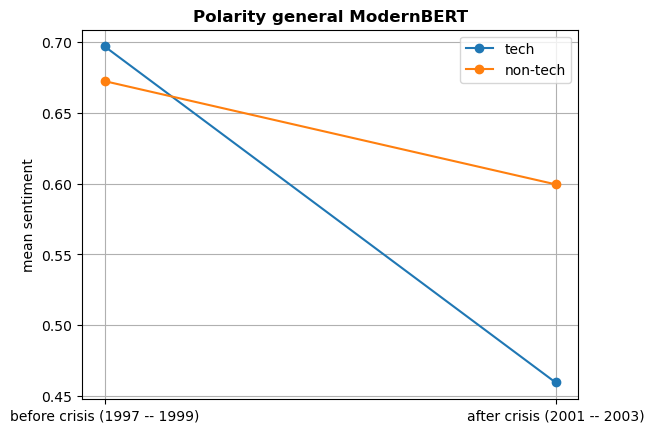

In [401]:
ending = "In summary, we are [MASK] regarding the future growth of our company."

tech_res, blue_chip_res = calc_tech_and_blue_chip_sent(model, blue_chip_dataloader, tech_dataloader, ending, sentiment_verb, text_length=q99)
tech_line, blue_chip_line, result_dict = calculate_mean_polarities(tech_res, blue_chip_res)

100%|██████████| 25/25 [01:03<00:00,  2.52s/it]


,before,after,delta
tech,0.6433,0.3149,0.3284
blue_chip,0.4964,0.4774,0.0190


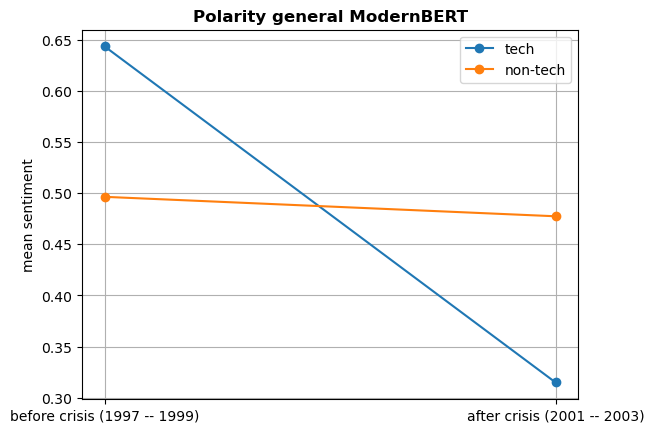

In [405]:
# ok
ending = "In one word, we are [MASK] regarding the future growth of our company."

tech_res, blue_chip_res = calc_tech_and_blue_chip_sent(model, blue_chip_dataloader, tech_dataloader, ending, sentiment_verb, text_length=q99)
tech_line, blue_chip_line, result_dict = calculate_mean_polarities(tech_res, blue_chip_res)

100%|██████████| 25/25 [01:06<00:00,  2.67s/it]


,before,after,delta
tech,0.3641,0.0635,0.3005
blue_chip,0.2904,0.2483,0.0421


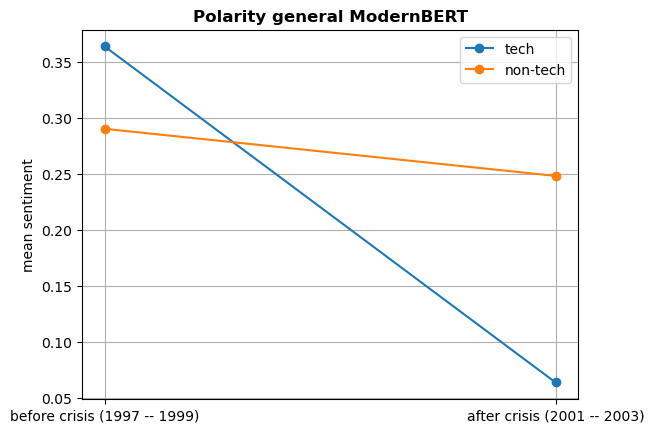

In [406]:
ending = "Regarding future growth, we are [MASK]."

sentiment_verb = {
    "positive": set(['optimistic', 'confident', 'positive', 'encouraged', 'excited',
                     'enthusiastic', 'hopeful', 'comfortable', 'satisfied', 'pleased', 
                     'relaxed', 'encouraged', 'ambitious', 'pleased', 'favorable', 
                     'assured', 'strong', 
             
                     ]),
    
    "negative": set(['cautious', 'concerned', 'aggressive', 'pessimistic', 'negative',
                     'uncomfortable', 'concerned', 'cautious', 'uncertain', 'unsure',
                     'skeptical', 'worried', 'discouraged', 'anxious', 'frustrated',
                     'confused', 'doubtful', 'unsatisfied', 'disappointed'
                    ])
}


tech_res, blue_chip_res = calc_tech_and_blue_chip_sent(model, blue_chip_dataloader, tech_dataloader, ending, sentiment_verb, text_length=q99)
tech_line, blue_chip_line, result_dict = calculate_mean_polarities(tech_res, blue_chip_res)

100%|██████████| 25/25 [01:04<00:00,  2.57s/it]


,before,after,delta
tech,0.0124,0.0290,-0.0167
blue_chip,0.0407,0.0005,0.0402


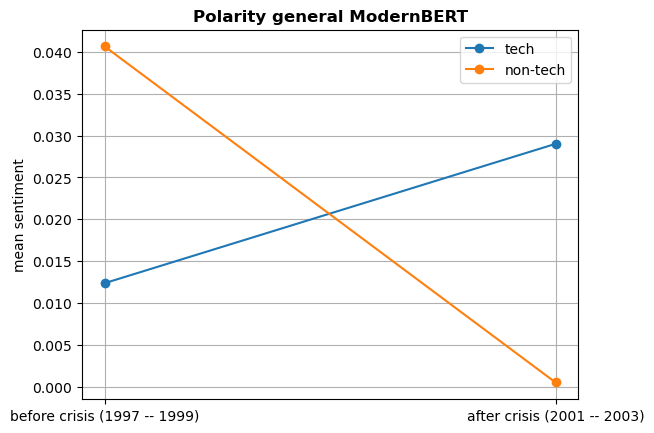

In [402]:
ending = "In one word, the company's next period profit is going to be [MASK]."

sentiment_verb = {
    "positive": set(['good', 'best', 'excellent', 'outstanding', 'exceptional',
                     'healthy', 'strong', 'awesome', 'great', 'fantastic', 'stable',
                     'perfect', 'solid', 'profitable', 'impressive', 'reliable',
                     'thriving', 'optimistic', 'decent', 'positive', 'sustainable',]),
    
    "negative": set(['bad', 'poor', 'terrible', 'risky', 'weak', 'dependent',
                     'unstable', 'unhealthy', 'questionable', 'suffering', 'stressed',
                     'fragile', 'negative', 'unsustainable', 'awful', 'vulnerable',
                     'mediocre', 'horrible', 'precarious', 'declining', 'worsening'])
}

tech_res, blue_chip_res = calc_tech_and_blue_chip_sent(model, blue_chip_dataloader, tech_dataloader, ending, sentiment_verb, text_length=q99)
tech_line, blue_chip_line, result_dict = calculate_mean_polarities(tech_res, blue_chip_res)

100%|██████████| 25/25 [01:06<00:00,  2.67s/it]


,before,after,delta
tech,-0.5596,-0.4999,-0.0597
blue_chip,-0.5171,-0.4972,-0.0199


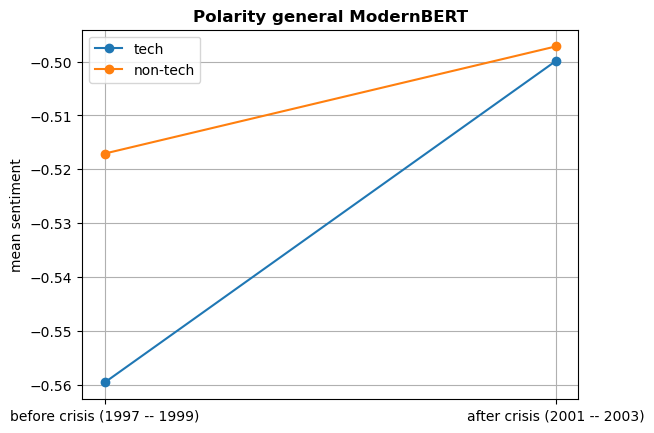

In [403]:
ending = "We project future growth, though with [MASK] confidence."

confidence_verbalizer = {
    "positive": {
        "high", "strong", "great", "full", "complete", "absolute",
        "total", "utmost", "maximum", "supreme", "unwavering",
        "unshakeable", "firm", "solid", "robust", "considerable"
    },
    
    "negative": {
        "low", "limited", "little", "some", "moderate", "cautious",
        "guarded", "measured", "tempered", "qualified", "conditional",
        "uncertain", "tentative", "hesitant", "wavering", "fragile",
        "minimal", "slight", "negligible", "weak", "diminished"
    }
}

tech_res, blue_chip_res = calc_tech_and_blue_chip_sent(model, blue_chip_dataloader, tech_dataloader, ending, confidence_verbalizer, text_length=q99)
tech_line, blue_chip_line, result_dict = calculate_mean_polarities(tech_res, blue_chip_res)

100%|██████████| 25/25 [01:03<00:00,  2.52s/it]


,before,after,delta
tech,-0.1331,-0.1411,0.0081
blue_chip,-0.1229,-0.1366,0.0137


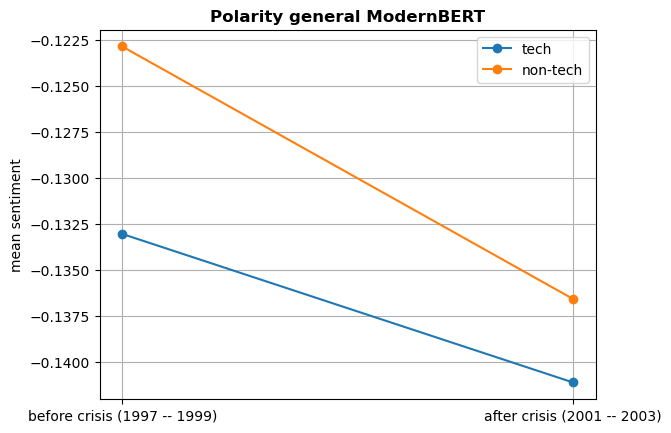

In [407]:
tech_res, blue_chip_res = calc_tech_and_blue_chip_sent(model, blue_chip_dataloader, tech_dataloader, ending, confidence_verbalizer, text_length=q99)
tech_line, blue_chip_line, result_dict = calculate_mean_polarities(tech_res, blue_chip_res)